In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.interpolate import UnivariateSpline
import pandas as pd
legend_font = 10
axes_font = 12
label_font = 11
plot_linewidth = 2
axes_linewidth = 0.9

In [54]:
# Functions for PPLN
def ne_LN(lambda_um, T_C):
    """
    Extraordinary refractive index of LiNbO3
    lambda_um : wavelength in micrometers
    T_C       : temperature in Celsius
    """

    # Temperature-dependent parameter
    f = (T_C - 24.5) * (T_C + 570.82)

    # Extraordinary index coefficients
    a1 = 5.756
    a2 = 0.0983
    a3 = 0.202
    a4 = 189.32
    a5 = 12.52
    a6 = 1.32e-2

    b1 = 2.860e-6
    b2 = 4.700e-8
    b3 = 6.113e-8
    b4 = 1.516e-4

    # Sellmeier equation
    ne2 = (
        a1
        + b1 * f
        + (a2 + b2 * f) / (lambda_um**2 - (a3 + b3 * f) ** 2)
        + (a4 + b4 * f) / (lambda_um**2 - a5**2)
        - a6 * lambda_um**2
    )

    return np.sqrt(ne2)




def phase_mismatch_SHG(lambda_F_um, T_C, poling_period_um):
    """
    Returns Δk in rad/m
    """

    lambda_F = lambda_F_um * 1e-6
    Lambda = poling_period_um * 1e-6
    

    n_F = ne_LN(lambda_F * 1e6, T_C)
    n_SHG = ne_LN((lambda_F / 2) * 1e6, T_C)

    delta_k = (
        4 * np.pi * (n_SHG - n_F) / lambda_F
        - 2 * np.pi / Lambda
    )

    return delta_k


def efficiency_PPLN_function(
    lambda_F_um,
    T_C,
    L_mm,
    deff_pmV,
    poling_period_um
):

    eps0 = 8.85e-12
    c = 2.99792458e8

    lambda_F = lambda_F_um * 1e-6
    omega = 2 * np.pi * c / lambda_F

    L = L_mm * 1e-3
    deff = deff_pmV * 1e-12

    n_F = ne_LN(lambda_F * 1e6, T_C)
    n_SHG = ne_LN((lambda_F / 2) * 1e6, T_C)

    delta_k = phase_mismatch_SHG(
        lambda_F_um,
        T_C,
        poling_period_um
    )

    # numpy sinc(x)=sin(pi*x)/(pi*x)
    sinc_term = np.sinc(delta_k * L / (2 * np.pi))

    efficiency = (
        2 * deff**2 * omega**3 * L
        / (np.pi * eps0 * c**4 * n_SHG * n_F)
    ) * sinc_term**2

    return efficiency

Maximum efficiency: 0.022081
Wavelength at max efficiency: 1.07 nm


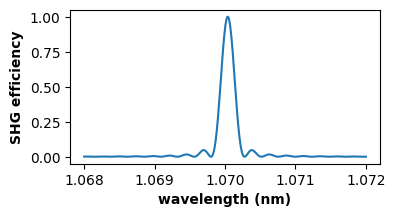

In [55]:
wavelength=np.linspace(1.068,1.072,500)
eta=efficiency_PPLN_function(
    lambda_F_um=wavelength,
    T_C=103,
    L_mm=10,
    deff_pmV=14.9,
    poling_period_um=6.96
)
plt.figure(figsize=(4,2))
plt.plot(wavelength,eta/eta.max())
plt.xlabel("wavelength (nm)",fontsize=10, fontweight='bold')
plt.ylabel("SHG efficiency",fontsize=10, fontweight='bold')

# Find wavelength at maximum efficiency
max_idx = np.argmax(eta)
lambda0 = wavelength[max_idx]
eta_max = eta[max_idx]

print(f"Maximum efficiency: {eta_max:.6f}")
print(f"Wavelength at max efficiency: {lambda0:.2f} nm")

In [56]:
wavelengths=np.linspace(1.06,1.200,100)
temperatures=np.linspace(70,200,100)
cal_pooling_period = np.zeros((len(wavelengths), len(temperatures)))

for i, wavelength_i in enumerate(wavelengths):
    for j, temperatures_j in enumerate(temperatures):
        sol = root_scalar(lambda z: phase_mismatch_SHG(wavelength_i, temperatures_j, z),bracket=[1, 20])
        cal_pooling_period[i, j] = sol.root


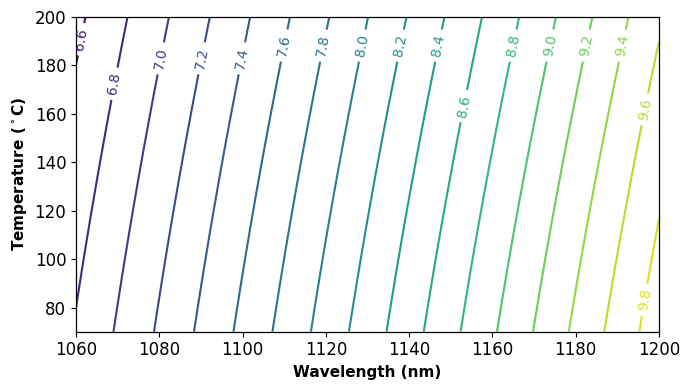

In [57]:

fig, ax = plt.subplots(figsize=(7, 4))
wavelengths, temperatures = np.meshgrid(wavelengths*1e3, temperatures, indexing='ij')
cs = plt.contour(wavelengths, temperatures, cal_pooling_period, levels=20)

plt.clabel(cs)

ax.set_xlabel("Wavelength (nm)",fontsize=label_font,fontweight="bold")
ax.set_ylabel("Temperature ($^\circ$C)",fontsize=label_font,fontweight="bold")

ax.tick_params(labelsize=axes_font)
for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)

# plt.savefig("pooling period.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [58]:
L=10e-3         # PPLN crystal length in meters
linewidth=[]   # Phase matching bandwidth in um

wavelengths=np.linspace(1.06,1.200,100)
# for i in range(len(wavelength1)):
for i in range(len(wavelengths)):
    lambda1=wavelengths[i]
    sol = root_scalar(lambda z: phase_mismatch_SHG(wavelengths[i], 100, z),bracket=[1, 20])

    pooling_period = sol.root
    lam_scan = np.linspace(lambda1-0.005, lambda1+0.005, 1000)

    
    dk = np.array([phase_mismatch_SHG(l, 100,pooling_period) for l in lam_scan])

    eff = (np.sinc(dk*L/(2*np.pi)))**2
    half_value = np.max(eff)*0.5
    spline = UnivariateSpline(lam_scan, eff-half_value, s=0)
    roots = spline.roots()  # Returns points where the spline crosses 0

    linewidth_val = roots[1] - roots[0]
    linewidth.append(linewidth_val)
    
linewidth = np.array(linewidth)

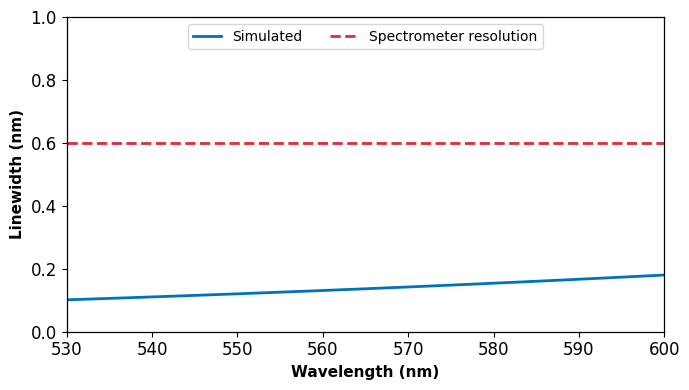

In [59]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    wavelengths* 0.5 * 1e3,
    linewidth* 0.5 *1e3,
    color="#0072BD",
    linewidth=plot_linewidth,
    label="Simulated",
)
ax.plot(
    wavelengths* 0.5 * 1e3,
    0.6*np.ones(len(wavelengths)),
    color="#DB2E37",
    linewidth=plot_linewidth,
    linestyle='--',
    label="Spectrometer resolution",
)


ax.set_xlabel("Wavelength (nm)",fontsize=label_font,fontweight="bold")
ax.set_ylabel("Linewidth (nm)",fontsize=label_font,fontweight="bold")
ax.set_xlim([530, 600])
ax.set_ylim([0, 1])

ax.tick_params(labelsize=axes_font)
for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)

ax.legend(fontsize=legend_font,loc="upper center",ncol=2)
plt.savefig("PPLN linewidth.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()